# CAISO Demand Forecasting with pyKAN — Regional Weather

Same as `cs_pykan.ipynb` but uses per-station weather features instead of a statewide average.

- **Input (34 features):** 20 per-station weather (4 stations × 5 vars) + economic + cyclical-calendar (sin/cos) + lag-1h / lag-24h / lag-72h / lag-168h / lag-336h
- **Architecture:** `[34 → 32 → 1]` with B-spline activations (k=4)
- **Training:** coarse grid=3 (1000 steps) → refine grid=5 (1000 steps) → refine grid=7 (500 steps)
- **Data:** `combined_hourly_regional.csv` — run `pullWeather_regional.ipynb` → `cleanCombine_regional.ipynb` first

In [9]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from kan import KAN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA = '../../data/processed/combined_hourly_regional.csv'

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]  # 20 cols

# Non-weather, non-cyclical features
OTHER_FEATURES = ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                  'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

FEATURES   = WEATHER_COLS + OTHER_FEATURES  # 29 total before lags
SCALE_COLS = ['load_mw', 'gas_price_mmbtu'] + WEATHER_COLS  # cyclical/binary don't need scaling

TARGET = 'load_mw'

torch.manual_seed(1)

### 1. Load & lag features

In [10]:
df = pd.read_csv(DATA, parse_dates=['datetime'], index_col='datetime')

# Cyclical calendar encoding
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# Lag features — 1h, 24h, 72h, 168h (1 week), 336h (2 weeks)
df['load_lag1']   = df[TARGET].shift(1)
df['load_lag24']  = df[TARGET].shift(24)
df['load_lag72']  = df[TARGET].shift(72)
df['load_lag168'] = df[TARGET].shift(168)
df['load_lag336'] = df[TARGET].shift(336)
df = df.dropna()

LAG_FEATURES = FEATURES + ['load_lag1', 'load_lag24', 'load_lag72', 'load_lag168', 'load_lag336']
print(f'{len(df):,} rows | {len(LAG_FEATURES)} input features')

52,283 rows | 34 input features


### 2. Split then standardise (train stats only)

In [11]:
split = int(len(df) * 0.8)
train_raw, test_raw = df.iloc[:split].copy(), df.iloc[split:].copy()
print(f'Train: {len(train_raw):,}  {train_raw.index[0].date()} to {train_raw.index[-1].date()}')
print(f'Test:  {len(test_raw):,}   {test_raw.index[0].date()} to {test_raw.index[-1].date()}')

LAG_SCALE = SCALE_COLS + ['load_lag1', 'load_lag24', 'load_lag72', 'load_lag168', 'load_lag336']
scaler = {col: {'mean': train_raw[col].mean(), 'std': train_raw[col].std()}
          for col in LAG_SCALE}

train, test = train_raw.copy(), test_raw.copy()
for col, s in scaler.items():
    train[col] = (train[col] - s['mean']) / s['std']
    test[col]  = (test[col]  - s['mean']) / s['std']

load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')

def to_tensor(frame, cols):
    return torch.tensor(frame[cols].values, dtype=torch.float32)

dataset = {
    'train_input': to_tensor(train, LAG_FEATURES),
    'train_label': to_tensor(train, [TARGET]),
    'test_input':  to_tensor(test,  LAG_FEATURES),
    'test_label':  to_tensor(test,  [TARGET]),
}
print('train_input shape:', dataset['train_input'].shape)

Train: 41,826  2019-01-15 to 2023-10-23
Test:  10,457   2023-10-23 to 2024-12-31
load_mw  mean=24978.7 MW  std=4132.1 MW  (train only)
train_input shape: torch.Size([41826, 34])


### 3. Build & train KAN

In [12]:
model = KAN(width=[len(LAG_FEATURES), 64, 1], grid=5, k=4, seed=42)

print('=== Phase 1: grid=3, 1000 steps ===')
results1 = model.fit(
    dataset, opt='Adam', lr=1e-3,
    steps=1000, batch=2048,
    update_grid=True, lamb=0.0001, log=100,
)


checkpoint directory created: ./model
saving model version 0.0
=== Phase 1: grid=3, 1000 steps ===


| train_loss: 7.09e-02 | test_loss: 1.22e-01 | reg: 8.77e+01 | : 100%|█| 1000/1000 [04:40<00:00,  3.

saving model version 0.1


### 4. Loss curve

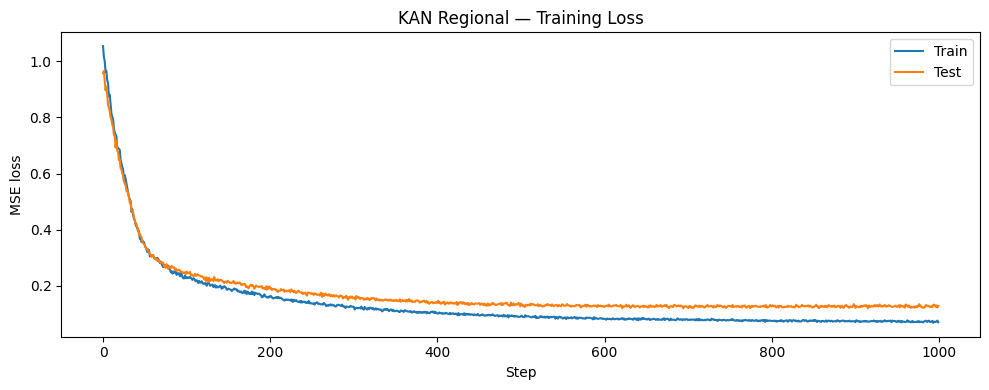

In [17]:
train_loss = results1['train_loss']
test_loss  = results1['test_loss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train')
ax.plot(test_loss,  label='Test')
ax.set_xlabel('Step')
ax.set_ylabel('MSE loss')
ax.set_title('KAN Regional — Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

### 5. Evaluate on test set

In [14]:
model.eval()
with torch.no_grad():
    pred = model(dataset['test_input']).squeeze().numpy()

y_true = dataset['test_label'].squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'KAN Regional (per-station weather, train-only scaler)')
print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'  R2    {r2:.4f}')

KAN Regional (per-station weather, train-only scaler)
  RMSE  0.1273  (526 MW)
  MAE   0.0932  (385 MW)
  R2    0.9826


### 6. Predictions vs actuals (first 2 weeks of test)

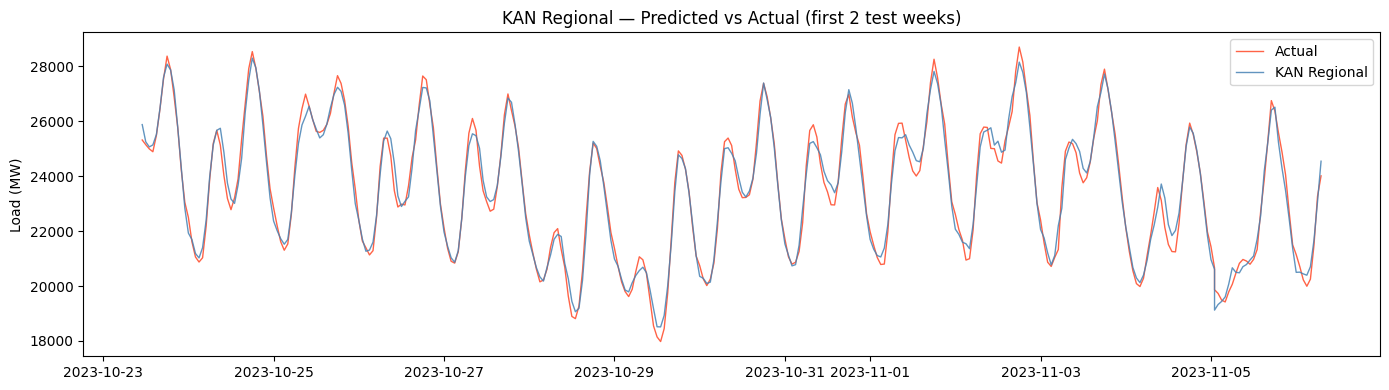

In [15]:
n      = 24 * 14
idx    = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual,                          color='tomato',    linewidth=1,        label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='KAN Regional')
ax.set_ylabel('Load (MW)')
ax.set_title('KAN Regional — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()

### 7. KAN symbolic plot

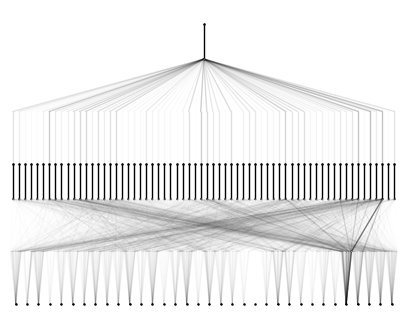

In [16]:
model.plot(beta=3)